In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv


In [45]:
# See what columns currently exist
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [46]:
# Clean up EDUCATION: collapse undocumented codes (0, 5, 6) into "others" (4)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Clean up MARRIAGE: collapse undocumented code (0) into "others" (3)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# Check how balanced the target is
print(df['default'].value_counts(normalize=True))

# Confirm no missing values
print("\nMissing values per column:\n", df.isnull().sum().sum())

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Missing values per column:
 0


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Separate features (X) from target (y)
X = df.drop(columns=['default'])
y = df['default']

# Split into training (75%) and testing (25%) sets
# random_state=42 makes this reproducible - same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Scale features - logistic regression performs better when features are on similar scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict probabilities on the test set
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

# Evaluate
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nLogistic Regression AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training set: (22500, 23)
Test set: (7500, 23)

Logistic Regression AUC: 0.7157

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      5841
           1       0.70      0.24      0.36      1659

    accuracy                           0.81      7500
   macro avg       0.76      0.61      0.62      7500
weighted avg       0.79      0.81      0.77      7500



In [48]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # Note: tree models don't need scaled features

rf_pred_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print(f"Random Forest AUC: {rf_auc:.4f}")

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='logloss',
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
)
xgb.fit(X_train, y_train)

xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
print(f"XGBoost AUC: {xgb_auc:.4f}")

# --- Compare all three models ---
print("\n--- Model Comparison ---")
print(f"Logistic Regression AUC: {auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"XGBoost AUC:              {xgb_auc:.4f}")

Random Forest AUC: 0.7755
XGBoost AUC: 0.7755

--- Model Comparison ---
Logistic Regression AUC: 0.7157
Random Forest AUC:       0.7755
XGBoost AUC:              0.7755


In [49]:
# Print more decimal places to check if they're truly identical or just rounded the same
print(f"Random Forest AUC (full precision): {rf_auc:.8f}")
print(f"XGBoost AUC (full precision):       {xgb_auc:.8f}")

# Sanity check: are the actual predictions different?
print("\nAre RF and XGBoost predictions identical?", np.array_equal(rf_pred_proba, xgb_pred_proba))
print("First 5 RF probabilities: ", rf_pred_proba[:5])
print("First 5 XGB probabilities:", xgb_pred_proba[:5])

Random Forest AUC (full precision): 0.77554300
XGBoost AUC (full precision):       0.77545729

Are RF and XGBoost predictions identical? False
First 5 RF probabilities:  [0.7005229  0.71179095 0.49989167 0.76930624 0.45231357]
First 5 XGB probabilities: [0.71702385 0.7012199  0.4475469  0.7023732  0.50569636]


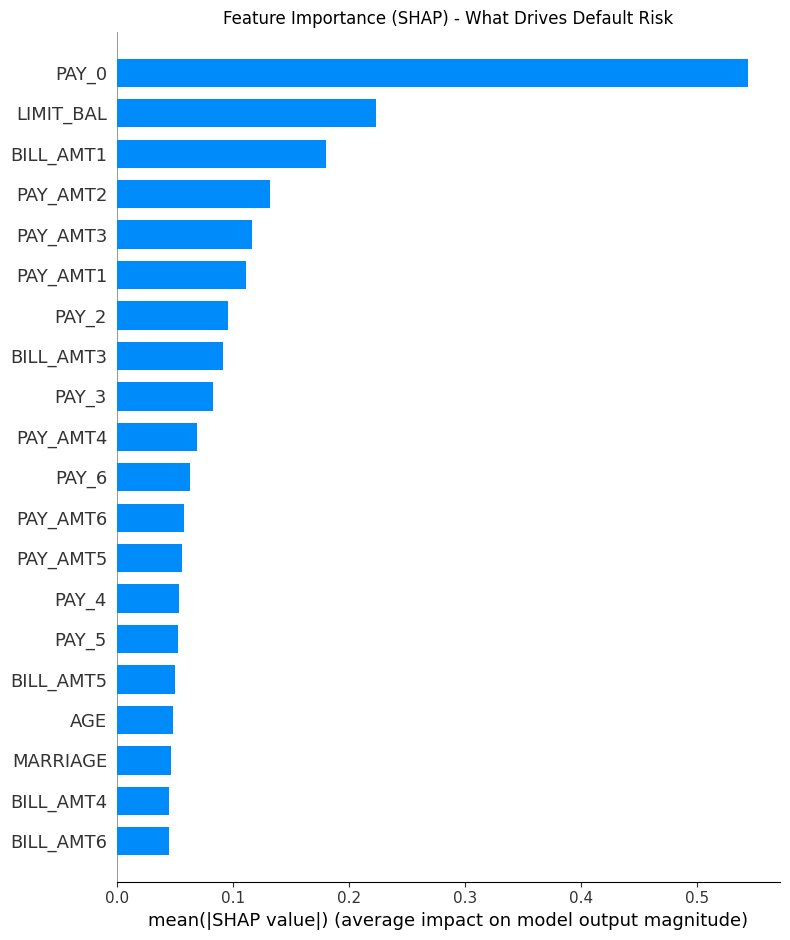

In [50]:
import shap

# SHAP explains XGBoost's predictions - which features push risk up or down
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot: shows the most important features overall
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
import matplotlib.pyplot as plt
plt.title("Feature Importance (SHAP) - What Drives Default Risk")
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance.png', dpi=150)
plt.show()

In [51]:
print("""
SUMMARY OF FINDINGS
====================
Dataset: 30,000 credit card clients, Taiwan (2005)
Task: Predict whether a client will default on payment next month

Model Performance (AUC):
  Logistic Regression:  0.7157
  Random Forest:        0.7755
  XGBoost:               0.7755

Key finding: Recent repayment status (PAY_0, i.e. whether the client
is currently behind on payment) is the single strongest predictor of
default risk, ahead of credit limit, bill amounts, and demographics.

This aligns with standard credit risk practice: recent payment behavior
is generally a stronger predictor of near-term default than static
demographic or credit-limit variables.
""")


SUMMARY OF FINDINGS
Dataset: 30,000 credit card clients, Taiwan (2005)
Task: Predict whether a client will default on payment next month

Model Performance (AUC):
  Logistic Regression:  0.7157
  Random Forest:        0.7755
  XGBoost:               0.7755

Key finding: Recent repayment status (PAY_0, i.e. whether the client
is currently behind on payment) is the single strongest predictor of
default risk, ahead of credit limit, bill amounts, and demographics.

This aligns with standard credit risk practice: recent payment behavior
is generally a stronger predictor of near-term default than static
demographic or credit-limit variables.



In [52]:
import shap
import matplotlib.pyplot as plt

# Use a smaller sample for speed and reliability
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

fig = plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title("Feature Importance (SHAP) - What Drives Default Risk")
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance.png', dpi=150)
plt.close(fig)
print("SHAP plot saved successfully.")

SHAP plot saved successfully.
